# Thesis Figures Generator

## Macro-Aviation-Tourism Demand Modelling and Forecasting for Poland

**Author:** Diego Marrero Ferrera  
**Repository:** [GitHub — Macro-Aviation-Tourism-Modeling](https://github.com/DieGodMF4/Macro-Aviation-Tourism-Modeling)  
**Last updated:** 2026-05

---

### Purpose

This notebook generates the figures of the thesis memoir that are **not** produced by the analysis notebooks (NB00–NB09). It produces visualisations that integrate data from multiple raw datasets specifically for the thesis manuscript and that do not belong logically to any individual analysis stage.

Figures produced here:

- **Figure 1.1** — Tourism contribution to GDP across European countries (WTTC data).
- **Figure 1.2** — Parallel growth of air passengers and GDP per capita of Poland since EU accession (2004–2024).
- **Figure 2.1** — Polish air traffic with LCC penetration and origin-market share (combined panel).

All figures follow the project's plot conventions (paths, palette, COVID shading, savefig).

## 0. Environment & Configuration

In [34]:
import pandas as pd
import numpy as np
import os
import warnings

warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns

# --- PLOT SETTINGS (matching project convention) ---
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('notebook', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'font.size': 10,
    'legend.fontsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
    'lines.linewidth': 2.0,
    'lines.markersize': 6,
    'savefig.bbox': 'tight',
    'savefig.dpi': 200,
    'savefig.facecolor': 'white',
})

# Consistent palette across the project
COLORS = {
    'primary':   '#2c3e50',
    'secondary': '#e74c3c',
    'accent1':   '#3498db',
    'accent2':   '#2ecc71',
    'accent3':   '#f39c12',
    'accent4':   '#9b59b6',
    'gray':      '#95a5a6',
    'covid':     '#e74c3c',
}

COVID_START = pd.Timestamp('2020-03-01')
COVID_END   = pd.Timestamp('2021-06-30')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Environment ready.')

Environment ready.


In [35]:
# --- PROJECT PATHS ---
# This notebook lives at: /documentation_es/scripts-generate-figs/nb-figures.ipynb
# Therefore data/raw is two levels up.
DATA_RAW  = os.path.join('..', '..', 'data', 'raw')
FIG_DIR   = os.path.join('..', 'figures-memoria')
os.makedirs(FIG_DIR, exist_ok=True)

# --- FILE CATALOGUE (mirroring NB01's structure) ---
FILES = {
    # Transport
    'avia_seats':    os.path.join(DATA_RAW, 'transport',
                        'avia_tf_aca__seats-flights-pass-PL-2010-.csv'),
    'avia_pax':      os.path.join(DATA_RAW, 'transport',
                        'avia_paoc__passengers-countries.csv'),
    'avia_airports': os.path.join(DATA_RAW, 'transport',
                        'avia_tf_apal_passengers_airports_PL-2003-.csv'),
    # Economic
    'gdp_real':      os.path.join(DATA_RAW, 'economic',
                        'namq_10_gdp__real-gdp-CLV-2010.csv'),
    'gdp_nominal':   os.path.join(DATA_RAW, 'economic',
                        'namq_10_gdp__market_prices.csv'),
    # Demographic
    'population':    os.path.join(DATA_RAW, 'demographic',
                        'demo_pjan__population-eur-990-25.csv'),
}

print('File verification:')
for name, path in FILES.items():
    tag = 'OK' if os.path.exists(path) else 'MISSING'
    print(f'  [{tag}] {name}: {os.path.basename(path)}')

File verification:
  [OK] avia_seats: avia_tf_aca__seats-flights-pass-PL-2010-.csv
  [OK] avia_pax: avia_paoc__passengers-countries.csv
  [OK] avia_airports: avia_tf_apal_passengers_airports_PL-2003-.csv
  [OK] gdp_real: namq_10_gdp__real-gdp-CLV-2010.csv
  [OK] gdp_nominal: namq_10_gdp__market_prices.csv
  [OK] population: demo_pjan__population-eur-990-25.csv


In [36]:
# --- HELPER FUNCTIONS (matching NB01 conventions) ---
NAME_TO_CODE = {
    'Austria': 'AT', 'Croatia': 'HR', 'Czechia': 'CZ',
    'France': 'FR', 'Germany': 'DE', 'Greece': 'EL',
    'Hungary': 'HU', 'Italy': 'IT', 'Netherlands': 'NL',
    'Poland': 'PL', 'Spain': 'ES', 'Sweden': 'SE',
    'United Kingdom': 'UK', 'United States': 'US',
    'European Union - 27 countries (from 2020)': 'EU27',
    'Euro area – 20 countries (from 2023)': 'EA20',
}


def load_eurostat(path, parse_dates=True):
    """Load an Eurostat CSV and parse TIME_PERIOD to datetime if requested."""
    df = pd.read_csv(path)
    if parse_dates and 'TIME_PERIOD' in df.columns:
        tp = df['TIME_PERIOD'].astype(str)
        if tp.str.match(r'^\d{4}-\d{2}$').all():
            df['date'] = pd.to_datetime(tp, format='%Y-%m')
        elif tp.str.match(r'^\d{4}-Q\d$').all():
            df['date'] = pd.PeriodIndex(tp, freq='Q').to_timestamp()
        elif tp.str.match(r'^\d{4}$').all():
            df['date'] = pd.to_datetime(tp, format='%Y')
        else:
            df['date'] = pd.to_datetime(tp, errors='coerce')
    return df


def add_geo_code(df):
    if 'geo' in df.columns:
        df['iso'] = df['geo'].map(NAME_TO_CODE)
    return df


def covid_shade(ax):
    ax.axvspan(COVID_START, COVID_END, alpha=0.10, color=COLORS['covid'],
               label='COVID-19 period')


def format_year_axis(ax, interval=2):
    ax.xaxis.set_major_locator(mdates.YearLocator(interval))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))


def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, name), dpi=200, bbox_inches='tight')


print('Helper functions defined.')

Helper functions defined.


---

## Figure 1.1 — Tourism Contribution to GDP by European Country (WTTC 2024)

Sourced from the WTTC *Travel & Tourism Economic Impact* 2024 release. The values represent total contribution of travel and tourism to each country's GDP as a percentage. Since the WTTC data is not part of the project's raw data files, the values are entered manually as constants and the figure compares Poland with a selection of representative European tourism economies.

**Source:** WTTC (2025). *Travel & Tourism Economic Impact 2025.* World Travel & Tourism Council. https://wttc.org/

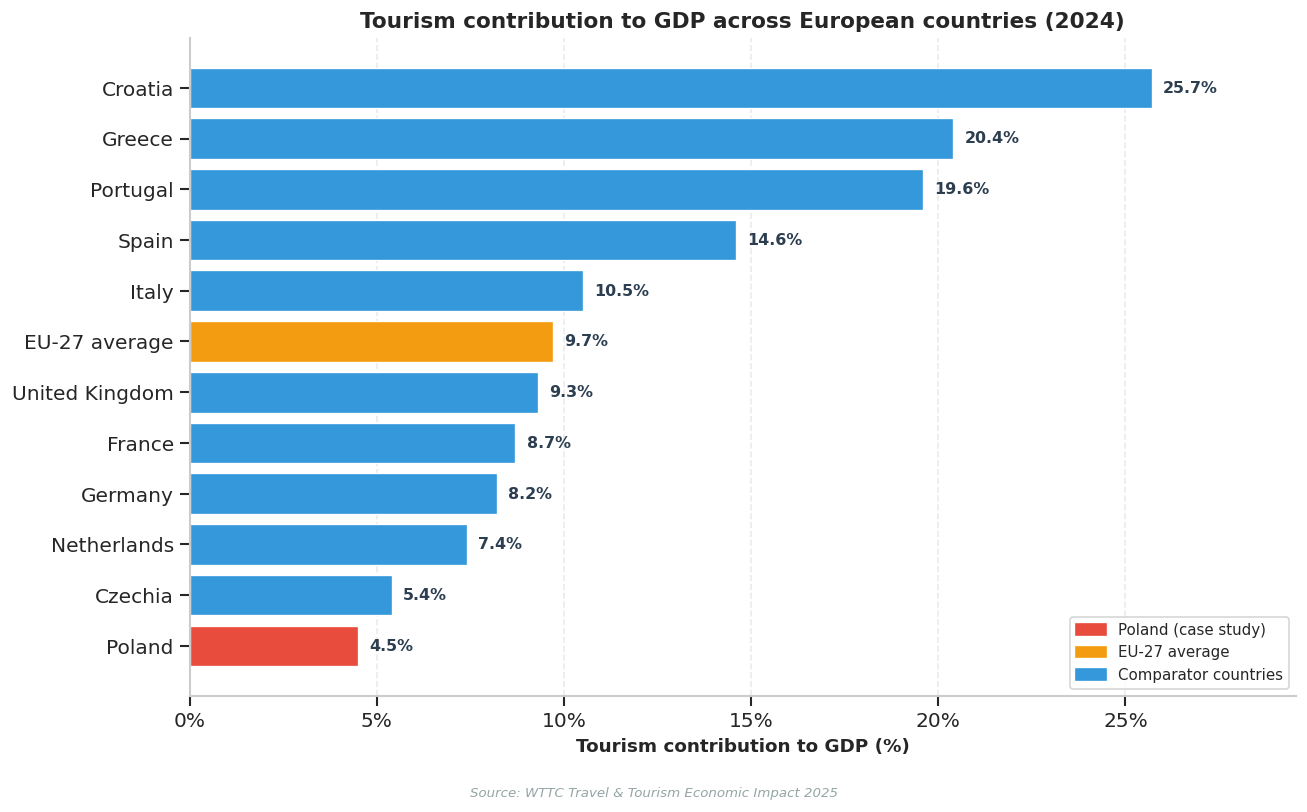

In [37]:
# WTTC 2024 — total contribution of travel & tourism to GDP, % of country GDP
# Values are approximate and should be verified against the latest WTTC report before final submission
wttc_data = pd.DataFrame([
    ('Croatia',     25.7, 'HR'),
    ('Greece',      20.4, 'EL'),
    ('Portugal',    19.6, 'PT'),
    ('Spain',       14.6, 'ES'),
    ('Italy',       10.5, 'IT'),
    ('EU-27 average', 9.7, 'EU27'),
    ('France',       8.7, 'FR'),
    ('Germany',      8.2, 'DE'),
    ('United Kingdom', 9.3, 'UK'),
    ('Netherlands',  7.4, 'NL'),
    ('Czechia',      5.4, 'CZ'),
    ('Poland',       4.5, 'PL'),
], columns=['country', 'gdp_share', 'iso'])
wttc_data = wttc_data.sort_values('gdp_share', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 6.5))

# Colour-code: Poland in red, EU-27 average in orange, others in blue
bar_colors = []
for c in wttc_data['country']:
    if c == 'Poland':
        bar_colors.append(COLORS['secondary'])
    elif c == 'EU-27 average':
        bar_colors.append(COLORS['accent3'])
    else:
        bar_colors.append(COLORS['accent1'])

bars = ax.barh(wttc_data['country'], wttc_data['gdp_share'],
                color=bar_colors, edgecolor='white', linewidth=0.8)

# Value labels on each bar
for bar, val in zip(bars, wttc_data['gdp_share']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}%',
             va='center', fontsize=9.5, fontweight='bold',
             color=COLORS['primary'])

ax.set_xlabel('Tourism contribution to GDP (%)', fontweight='bold')
ax.set_title('Tourism contribution to GDP across European countries (2024)',
              fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_xlim(0, max(wttc_data['gdp_share']) * 1.15)
ax.grid(axis='y', alpha=0)
ax.grid(axis='x', alpha=0.4)

# Legend with custom patches
from matplotlib.patches import Patch
legend_handles = [
    Patch(color=COLORS['secondary'], label='Poland (case study)'),
    Patch(color=COLORS['accent3'],   label='EU-27 average'),
    Patch(color=COLORS['accent1'],   label='Comparator countries'),
]
ax.legend(handles=legend_handles, loc='lower right', frameon=True)

# Footer with source
fig.text(0.5, -0.03,
         'Source: WTTC Travel & Tourism Economic Impact 2025',
         ha='center', fontsize=8, style='italic', color=COLORS['gray'])

plt.tight_layout()
savefig('fig_1_1_tourism_gdp_share.png')
plt.show()

---

## Figure 1.2 — Parallel Growth of Air Connectivity and GDP per Capita of Poland (2004–2024)

Double-axis chart showing the parallel evolution of two complementary indicators of Poland's economic and connectivity convergence since EU accession in 2004. The left axis tracks total air passengers at Polish airports; the right axis tracks GDP per capita relative to the EU-27 average. The chart highlights the COVID-19 disruption and the differentiated recovery.

**Data sources:**
- Passengers: Eurostat `avia_tf_apal` (passengers by airport, Poland).
- GDP and population: Eurostat `namq_10_gdp` (nominal GDP at market prices) and `demo_pjan` (population on 1 January).

In [38]:
# --- LOAD AND AGGREGATE PASSENGER DATA ---
pax = load_eurostat(FILES['avia_airports'])
print('avia_airports columns:', list(pax.columns))
print('Sample row:')
print(pax.head(2))

avia_airports columns: ['DATAFLOW', 'LAST UPDATE', 'freq', 'unit', 'tra_meas', 'airline', 'rep_airp', 'TIME_PERIOD', 'OBS_VALUE', 'OBS_FLAG', 'CONF_STATUS', 'date']
Sample row:
                  DATAFLOW        LAST UPDATE     freq       unit  \
0  ESTAT:AVIA_TF_APAL(1.0)  16/12/25 23:00:00  Monthly  Passenger   
1  ESTAT:AVIA_TF_APAL(1.0)  16/12/25 23:00:00  Monthly  Passenger   

             tra_meas       airline                      rep_airp TIME_PERIOD  \
0  Passengers carried  All airlines  BYDGOSZCZ/SZWEDEROWO airport     2008-01   
1  Passengers carried  All airlines  BYDGOSZCZ/SZWEDEROWO airport     2008-02   

   OBS_VALUE  OBS_FLAG  CONF_STATUS       date  
0      17441       NaN          NaN 2008-01-01  
1      15181       NaN          NaN 2008-02-01  


In [39]:
# Aggregate passengers annually across all Polish airports
pax['year'] = pax['date'].dt.year
# Sum across all months and all airports — total annual passengers in Poland
pax_annual = pax.groupby('year')['OBS_VALUE'].sum()
pax_annual = pax_annual.loc[2004:2024]

print(f'Air passengers in Poland — annual totals (2004–2024):')
print(pax_annual.apply(lambda x: f'{x/1e6:.2f}M').to_string())

Air passengers in Poland — annual totals (2004–2024):
year
2004     6.09M
2005     7.08M
2006     8.12M
2007     9.35M
2008    11.24M
2009     9.92M
2010    10.61M
2011    11.25M
2012    11.89M
2013    12.92M
2014    14.63M
2015    16.41M
2016    18.42M
2017    21.67M
2018    24.56M
2019    25.95M
2020     7.56M
2021    10.74M
2022    21.20M
2023    38.55M
2024    58.89M


In [40]:
# --- LOAD REAL GDP OF POLAND (chain-linked volumes, 2010 reference) ---
gdp_real = load_eurostat(FILES['gdp_real'])

print('gdp_real shape:', gdp_real.shape)
print('Unique geo values:', sorted(gdp_real['geo'].unique()))
print('Unique unit values:', gdp_real['unit'].unique())
print('Unique na_item values:', gdp_real['na_item'].unique())
print('Unique s_adj values:', gdp_real['s_adj'].unique())

gdp_real shape: (1459, 12)
Unique geo values: ['Austria', 'Croatia', 'Czechia', 'France', 'Germany', 'Hungary', 'Italy', 'Netherlands', 'Poland', 'Spain', 'Sweden', 'United Kingdom']
Unique unit values: ['Chain linked volumes (2010), million euro']
Unique na_item values: ['Gross domestic product at market prices']
Unique s_adj values: ['Seasonally and calendar adjusted data']


In [41]:
# Filter Poland: real GDP at market prices, chain-linked volumes 2010, SCA.
# All four filter values exist as a single unique value in this dataset,
# so the filter is straightforward.
gdp_pol = gdp_real[
    (gdp_real['geo'] == 'Poland') &
    (gdp_real['na_item'] == 'Gross domestic product at market prices') &
    (gdp_real['unit'] == 'Chain linked volumes (2010), million euro') &
    (gdp_real['s_adj'] == 'Seasonally and calendar adjusted data')
].copy()

# Aggregate quarterly to annual (sum of four quarters = annual GDP)
gdp_pol['year'] = gdp_pol['date'].dt.year
gdp_pol_annual = gdp_pol.groupby('year')['OBS_VALUE'].sum()
# Restrict to the same year range as the passenger series
gdp_pol_annual = gdp_pol_annual.loc[2004:2024]

print(f'\nPoland real GDP, annual (chain-linked volumes 2010, million EUR):')
print(gdp_pol_annual.apply(lambda x: f'{x:>12,.0f}').to_string())


Poland real GDP, annual (chain-linked volumes 2010, million EUR):
year
2004         278,766
2005         287,712
2006         305,739
2007         326,486
2008         340,528
2009         348,825
2010         360,356
2011         379,244
2012         385,454
2013         388,114
2014         403,003
2015         420,489
2016         433,874
2017         456,530
2018         484,608
2019         506,502
2020         496,256
2021         530,198
2022         559,491
2023         560,295
2024         576,868


In [42]:
# --- LOAD POLAND POPULATION ---
pop = load_eurostat(FILES['population'])

pop_pol = pop[pop['geo'] == 'Poland'].copy()
# population dataset is annual (1 January reading)
pop_pol['year'] = pop_pol['date'].dt.year
pop_pol_annual = pop_pol.set_index('year')['OBS_VALUE']

# --- COMPUTE REAL GDP PER CAPITA (EUR, chain-linked 2010) ---
common_years = gdp_pol_annual.index.intersection(pop_pol_annual.index)
common_years = sorted([y for y in common_years if 2004 <= y <= 2024])

# GDP is in millions of EUR, population in persons.
# Multiply by 1e6 to express the per-capita figure in EUR per inhabitant per year.
gdppc_real = (gdp_pol_annual.loc[common_years] /
              pop_pol_annual.loc[common_years]) * 1e6

print(f'Poland real GDP per capita (EUR, chain-linked 2010 reference):')
print(gdppc_real.apply(lambda x: f'EUR {x:>10,.0f}').to_string())
print(f'\nKey figures:')
print(f'  2004: EUR {gdppc_real.iloc[0]:,.0f}')
print(f'  2024: EUR {gdppc_real.iloc[-1]:,.0f}')
print(f'  Growth multiplier: x{gdppc_real.iloc[-1]/gdppc_real.iloc[0]:.2f}')

Poland real GDP per capita (EUR, chain-linked 2010 reference):
year
2004    EUR      7,299
2005    EUR      7,537
2006    EUR      8,013
2007    EUR      8,563
2008    EUR      8,934
2009    EUR      9,147
2010    EUR      9,477
2011    EUR      9,964
2012    EUR     10,127
2013    EUR     10,197
2014    EUR     10,600
2015    EUR     11,064
2016    EUR     11,428
2017    EUR     12,022
2018    EUR     12,761
2019    EUR     13,339
2020    EUR     13,074
2021    EUR     14,301
2022    EUR     15,167
2023    EUR     15,245
2024    EUR     15,752

Key figures:
  2004: EUR 7,299
  2024: EUR 15,752
  Growth multiplier: x2.16


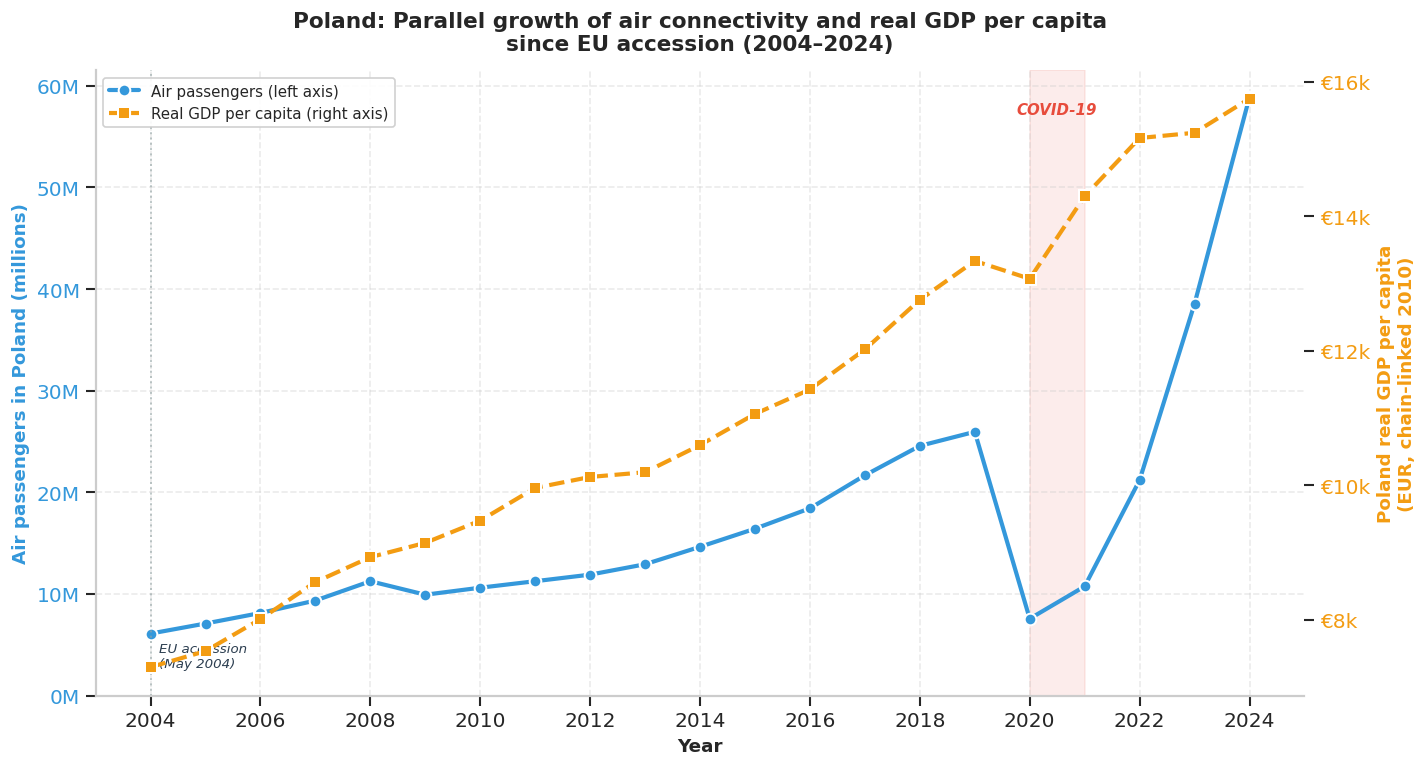

In [43]:
# --- BUILD THE FIGURE ---
fig, ax1 = plt.subplots(figsize=(12, 6.5))

# Left axis — Air passengers
color_pax = COLORS['accent1']
line1 = ax1.plot(pax_annual.index, pax_annual.values / 1e6,
                  marker='o', markersize=7, linewidth=2.5,
                  color=color_pax,
                  markeredgecolor='white', markeredgewidth=1.2,
                  label='Air passengers (left axis)')
ax1.set_xlabel('Year', fontweight='bold')
ax1.set_ylabel('Air passengers in Poland (millions)',
                color=color_pax, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_pax)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:.0f}M'))
ax1.set_ylim(bottom=0)

# Right axis — Real GDP per capita
ax2 = ax1.twinx()
color_gdp = COLORS['accent3']
line2 = ax2.plot(gdppc_real.index, gdppc_real.values,
                  marker='s', markersize=7, linewidth=2.5, linestyle='--',
                  color=color_gdp,
                  markeredgecolor='white', markeredgewidth=1.2,
                  label='Real GDP per capita (right axis)')
ax2.set_ylabel('Poland real GDP per capita\n(EUR, chain-linked 2010)',
                color=color_gdp, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_gdp)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'€{x/1000:.0f}k'))
ax2.grid(False)
ax2.spines['top'].set_visible(False)

# Vertical reference: EU accession in May 2004
ax1.axvline(2004, color=COLORS['gray'], linestyle=':', linewidth=1.2, alpha=0.6)
ax1.text(2004.15, ax1.get_ylim()[1] * 0.04,
          'EU accession\n(May 2004)',
          fontsize=8, color=COLORS['primary'],
          style='italic', va='bottom')

# COVID-19 shading
ax1.axvspan(2020, 2021, color=COLORS['covid'], alpha=0.10, zorder=0)
ax1.text(2020.5, ax1.get_ylim()[1] * 0.93,
          'COVID-19',
          fontsize=9, color=COLORS['secondary'],
          ha='center', fontweight='bold', style='italic')

# Combined legend (both axes)
ax1.legend(line1 + line2,
            [l.get_label() for l in line1 + line2],
            loc='upper left', frameon=True, framealpha=0.9)

# X-axis: tick every 2 years
ax1.set_xticks(range(2004, 2025, 2))
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x)}'))

plt.title('Poland: Parallel growth of air connectivity and real GDP per capita\n'
           'since EU accession (2004–2024)',
           fontweight='bold', pad=12)
plt.tight_layout()
savefig('fig_1_2_pax_gdp_poland.png')
plt.show()

In [44]:
# Summary statistics to quote in the thesis text (Chapter 1, Section 1.3)
print('Key figures for the thesis text:')
print(f'  Air passengers in 2004:           {pax_annual.loc[2004]/1e6:.1f}M')
print(f'  Air passengers in 2024:           {pax_annual.loc[2024]/1e6:.1f}M')
print(f'  Passenger growth multiplier:      x{pax_annual.loc[2024]/pax_annual.loc[2004]:.1f}')
print(f'  Real GDP per capita 2004:         EUR {gdppc_real.iloc[0]:,.0f}')
print(f'  Real GDP per capita 2024:         EUR {gdppc_real.iloc[-1]:,.0f}')
print(f'  GDP per capita growth multiplier: x{gdppc_real.iloc[-1]/gdppc_real.iloc[0]:.2f}')

Key figures for the thesis text:
  Air passengers in 2004:           6.1M
  Air passengers in 2024:           58.9M
  Passenger growth multiplier:      x9.7
  Real GDP per capita 2004:         EUR 7,299
  Real GDP per capita 2024:         EUR 15,752
  GDP per capita growth multiplier: x2.16


---

## Figure 2.1 — Polish Air Traffic Composition by Origin Country

Two-panel figure summarising the structure of air traffic between Poland and its main European source markets. Panel A shows the total passenger volume by origin country over the entire period; Panel B shows the market share as a pie chart. This figure incorporates the United Kingdom, whose chain-linked treatment was discussed in earlier presentations but is reproduced here for completeness.

**Source:** Eurostat `avia_paoc` (air passenger transport between reporting countries).

In [45]:
# --- LOAD AIR PASSENGERS BY COUNTRY OF ORIGIN ---
df_pax = load_eurostat(FILES['avia_pax'])
df_pax = add_geo_code(df_pax)

print('avia_pax columns:', list(df_pax.columns))
print('Sample of geo values:', df_pax['geo'].unique()[:10])
print(f'\nTotal rows: {len(df_pax):,}')

avia_pax columns: ['DATAFLOW', 'LAST UPDATE', 'freq', 'unit', 'tra_meas', 'tra_cov', 'schedule', 'geo', 'TIME_PERIOD', 'OBS_VALUE', 'OBS_FLAG', 'CONF_STATUS', 'date', 'iso']
Sample of geo values: ['Austria' 'Czechia' 'Germany' 'Greece' 'Spain' 'France' 'Croatia'
 'Hungary' 'Italy' 'Netherlands']

Total rows: 3,408


In [46]:
# Keep only the nine target origin countries (the same set used throughout the project)
ORIGIN_CODES = ['DE', 'UK', 'FR', 'NL', 'IT', 'ES', 'SE', 'AT', 'CZ']
df_pax_origins = df_pax[df_pax['iso'].isin(ORIGIN_CODES)].copy()

# Total passengers per origin over the entire period
pax_total = (df_pax_origins.groupby('iso')['OBS_VALUE']
             .sum()
             .sort_values(ascending=True))  # ascending for horizontal bar

print(f'Total passengers by origin country (entire period):')
for iso, val in pax_total.sort_values(ascending=False).items():
    print(f'  {iso}: {val/1e6:>7.1f}M')

Total passengers by origin country (entire period):
  ES:  3967.1M
  DE:  3895.1M
  UK:  3768.1M
  FR:  2886.9M
  IT:  2698.3M
  NL:  1321.7M
  SE:   635.5M
  AT:   571.4M
  CZ:   279.8M


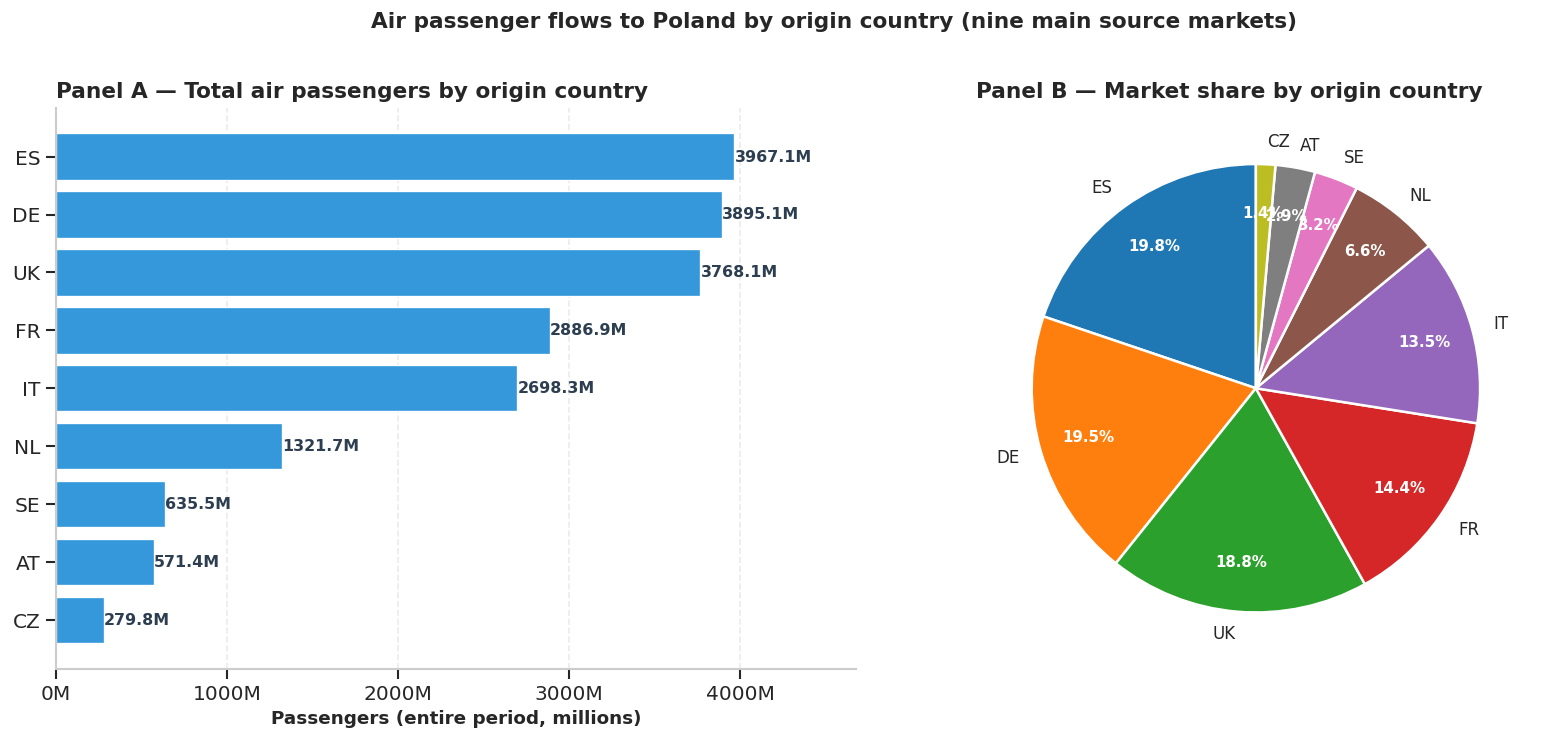


Market shares (verified):
  ES: 19.8%
  DE: 19.5%
  UK: 18.8%
  FR: 14.4%
  IT: 13.5%
  NL: 6.6%
  SE: 3.2%
  AT: 2.9%
  CZ: 1.4%


In [47]:
# --- BUILD THE TWO-PANEL FIGURE ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# === PANEL A — Total passengers by origin (horizontal bar) ===
ax_a = axes[0]
bars = ax_a.barh(pax_total.index, pax_total.values / 1e6,
                  color=COLORS['accent1'], edgecolor='white', linewidth=0.8)

# Value labels
for bar, val in zip(bars, pax_total.values):
    ax_a.text(val/1e6 + 1, bar.get_y() + bar.get_height()/2,
               f'{val/1e6:.1f}M',
               va='center', fontsize=9.5, fontweight='bold',
               color=COLORS['primary'])

ax_a.set_xlabel('Passengers (entire period, millions)', fontweight='bold')
ax_a.set_title('Panel A — Total air passengers by origin country',
                fontweight='bold', loc='left')
ax_a.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f'{x:.0f}M'))
ax_a.set_xlim(0, pax_total.max()/1e6 * 1.18)
ax_a.grid(axis='y', alpha=0)
ax_a.grid(axis='x', alpha=0.4)

# === PANEL B — Market share pie chart ===
ax_b = axes[1]
shares = pax_total / pax_total.sum() * 100
shares_sorted = shares.sort_values(ascending=False)

# Build a colour list (highlight UK and DE as the largest)
pie_palette = sns.color_palette('tab10', n_colors=len(shares_sorted))

wedges, texts, autotexts = ax_b.pie(
    shares_sorted.values,
    labels=shares_sorted.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=pie_palette,
    wedgeprops=dict(edgecolor='white', linewidth=1.5),
    textprops=dict(fontsize=10),
    pctdistance=0.78,
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(9)
    autotext.set_fontweight('bold')

ax_b.set_title('Panel B — Market share by origin country',
                fontweight='bold', loc='left')

plt.suptitle('Air passenger flows to Poland by origin country '
              '(nine main source markets)',
              fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
savefig('fig_2_1_origin_country_traffic.png')
plt.show()

# Print verified shares for the thesis text
print('\nMarket shares (verified):')
for iso, share in shares.sort_values(ascending=False).items():
    print(f'  {iso}: {share:.1f}%')

---

## Summary

All thesis-specific figures generated:

- `fig_1_1_tourism_gdp_share.png` — Tourism contribution to GDP by country (WTTC).
- `fig_1_2_pax_gdp_poland.png` — Air passengers vs GDP per capita relative to EU-27, Poland 2004–2024.
- `fig_2_1_origin_country_traffic.png` — Origin country composition of Polish air traffic, two panels.

The other figures of the thesis (4.3 to 5.8) are generated by the respective analysis notebooks (NB00–NB09) and should be exported from each of them following the naming convention used in the thesis manuscript.